In [3]:
import pandas as pd
import numpy as np
import ipaddress
import math
import re

print("1. Loading Normal and Malicious CSVs...\n")

columns_to_load = [
    'SystemTime', 'EventID', 'User', 'ProcessGuid', 'ParentProcessGuid', 'Image', 'ParentImage',
    'CommandLine', 'IntegrityLevel','TargetImage','StartModule','StartFunction','GrantedAccess', 'DestinationIp', 'DestinationPort',
    'Initiated', 'TargetFilename', 'QueryName', 'EventRecordID', 'Label' 
]

# Load Both and Concatenate
df_normal = pd.read_csv('data/Normal.csv', usecols=lambda c: c.strip() in columns_to_load, low_memory=False)
df_malicious = pd.read_csv('data/Malicious.csv', usecols=lambda c: c.strip() in columns_to_load, low_memory=False)

df_full = pd.concat([df_normal, df_malicious], ignore_index=True)
df_full.columns = df_full.columns.str.strip()

# Ensure Label is an integer (0 or 1)
df_full['Label'] = df_full['Label'].fillna(0).astype(int)

print(f"Total Logs Loaded: {len(df_full):,} ({len(df_normal):,} Normal, {len(df_malicious):,} Malicious)")

# Set up time
df_full['SystemTime'] = pd.to_datetime(df_full['SystemTime'], errors='coerce')
df_full = df_full.dropna(subset=['SystemTime']).rename(columns={'SystemTime': 'Time'})

print("2. Mapping Actors and dropping Machine Accounts...\n")
eid1_df = df_full[(df_full['EventID'] == 1) & (df_full['User'].notna())]
guid_to_user = eid1_df.drop_duplicates(subset=['ProcessGuid']).set_index('ProcessGuid')['User'].to_dict()
df_full['Actor'] = df_full['ProcessGuid'].map(guid_to_user)
df_full['Actor'] = df_full['Actor'].fillna(df_full.get('User', pd.Series([None]*len(df_full)))).fillna('UNKNOWN_ACTOR')

machine_keywords = ['AUTHORITY', 'Window Manager', 'DWM', 'UMFD', 'NETWORK SERVICE', 'LOCAL SERVICE', 'SYSTEM']
is_machine = df_full['Actor'].str.contains('|'.join(machine_keywords), case=False, na=False)
df_human = df_full[~is_machine].copy()

print("3. Calculating Math & Stateful Features...\n")

# A. Unique IPs & Beaconing
eid3_mask = df_human['EventID'] == 3
df_human['unique_ips'] = 0
df_human['beaconing_interval_regularity'] = 0.0

if eid3_mask.sum() > 0:
    eid3_df = df_human[eid3_mask].copy()
    unique_ip_counts = eid3_df.groupby('ProcessGuid')['DestinationIp'].nunique().to_dict()
    df_human.loc[eid3_mask, 'unique_ips'] = df_human.loc[eid3_mask, 'ProcessGuid'].map(unique_ip_counts)
    
    eid3_df = eid3_df.sort_values(by=['ProcessGuid', 'DestinationIp', 'Time'])
    eid3_df['time_diff_seconds'] = eid3_df.groupby(['ProcessGuid', 'DestinationIp'])['Time'].diff().dt.total_seconds()
    
    def calc_beaconing_regularity(group):
        deltas = group['time_diff_seconds'].dropna()
        if len(deltas) < 2: return 0.0
        mu, sigma = deltas.mean(), deltas.std()
        if sigma == 0: return 1.0
        if mu == 0: return 0.0
        return round(1.0 - min(1.0, sigma / mu), 3)

    beacon_scores = eid3_df.groupby(['ProcessGuid', 'DestinationIp']).apply(calc_beaconing_regularity).reset_index()
    beacon_scores.columns = ['ProcessGuid', 'DestinationIp', 'beaconing_interval_regularity']
    
    df_human = df_human.drop(columns=['beaconing_interval_regularity'], errors='ignore')
    df_human = df_human.merge(beacon_scores, on=['ProcessGuid', 'DestinationIp'], how='left')
    df_human['beaconing_interval_regularity'] = df_human['beaconing_interval_regularity'].fillna(0.0)

# B. DNS Entropy
def calculate_shannon_entropy(domain_name):
    if pd.isna(domain_name) or len(str(domain_name)) == 0: return 0.0
    domain_str = str(domain_name).lower().replace('www.', '').split('.')[0]
    if len(domain_str) == 0: return 0.0
    prob = [float(domain_str.count(c)) / len(domain_str) for c in dict.fromkeys(list(domain_str))]
    return round(-sum([p * math.log(p) / math.log(2.0) for p in prob]), 3)

eid22_mask = df_human['EventID'] == 22
df_human['dns_entropy'] = 0.0
if eid22_mask.sum() > 0:
    df_human.loc[eid22_mask, 'dns_entropy'] = df_human.loc[eid22_mask, 'QueryName'].apply(calculate_shannon_entropy)

# C. Special Char Density (Obfuscation)
def calc_special_char_density(cmd):
    if pd.isna(cmd) or len(str(cmd)) == 0: return 0.0
    cmd_str = str(cmd)
    special_chars = len(re.findall(r'[^a-zA-Z0-9\s\.\-]', cmd_str))
    return round(special_chars / len(cmd_str), 3)

eid1_mask = df_human['EventID'] == 1
df_human['special_char_density'] = 0.0
if eid1_mask.sum() > 0:
    df_human.loc[eid1_mask, 'special_char_density'] = df_human.loc[eid1_mask, 'CommandLine'].apply(calc_special_char_density)

# D. Parent Integrity Mapping
if eid1_mask.sum() > 0:
    guid_to_integ = df_human[eid1_mask].set_index('ProcessGuid')['IntegrityLevel'].to_dict()
    df_human['ParentIntegrity'] = df_human['ParentProcessGuid'].map(guid_to_integ)

# E. Parent Process Spoofing Detection
eid5_mask = df_human['EventID'] == 5
df_human['is_parent_spoofed'] = 0
if eid5_mask.sum() > 0:
    guid_to_death_time = df_human[eid5_mask].set_index('ProcessGuid')['Time'].to_dict()
    df_human['ParentDeathTime'] = df_human['ParentProcessGuid'].map(guid_to_death_time)
    dead_parent_mask = eid1_mask & df_human['ParentDeathTime'].notna() & (df_human['ParentDeathTime'] < df_human['Time'])
    df_human.loc[dead_parent_mask, 'is_parent_spoofed'] = 1



# F. Calculate Time Delta safely
print("Calculating Chronological Time Deltas...")

# Sort safely without dropping corrupted rows
df_human = df_human.sort_values(by=['ProcessGuid', 'Time'], na_position='first')

# Calculate the difference in seconds
df_human['time_diff_seconds'] = df_human.groupby('ProcessGuid')['Time'].diff().dt.total_seconds()

# Fill empty values with 0.0 (First event gets 0.0, which means START)
df_human['time_diff_seconds'] = df_human['time_diff_seconds'].fillna(0.0)

# =======================================================
# F. NEW: Process Tree Depth Calculation
# =======================================================
print("Calculating Process Tree Depths...")

# 1. Isolate all Process Creations to build the tree map
eid1_df_temp = df_human[df_human['EventID'] == 1].drop_duplicates(subset=['ProcessGuid'])

# 2. Build the Child -> Parent dictionary
parent_map = dict(zip(eid1_df_temp['ProcessGuid'], eid1_df_temp['ParentProcessGuid']))

# 3. Define the recursive depth calculator
def calculate_tree_depth(guid, current_depth=1):
    # Prevent infinite loops in corrupted circular logs
    if current_depth > 15: 
        return 15
        
    parent_guid = parent_map.get(guid)
    
    # If the parent exists in our dataset, go one level deeper!
    if parent_guid and parent_guid in parent_map:
        return calculate_tree_depth(parent_guid, current_depth + 1)
        
    # If there is no parent, we hit the root. Return the final depth.
    return current_depth

# 4. Map this depth back to the main dataframe for every row
depth_dict = {guid: calculate_tree_depth(guid) for guid in parent_map.keys()}
df_human['tree_depth'] = df_human['ProcessGuid'].map(depth_dict).fillna(1.0)


# =======================================================
# G. NEW: Network-to-Execution Delay Calculation
# =======================================================
print("Calculating Network-to-Execution Delays...")

# 1. We need the exact start time of every process (Event 1)
eid1_times = df_human[df_human['EventID'] == 1].drop_duplicates(subset=['ProcessGuid'])
guid_to_start_time = dict(zip(eid1_times['ProcessGuid'], eid1_times['Time']))

# 2. We need the exact time of the FIRST network connection (Event 3) for each process
eid3_times = df_human[df_human['EventID'] == 3].sort_values(by=['ProcessGuid', 'Time'])
first_eid3_times = eid3_times.drop_duplicates(subset=['ProcessGuid'], keep='first')
guid_to_first_net_time = dict(zip(first_eid3_times['ProcessGuid'], first_eid3_times['Time']))

# 3. Calculate the delay for all processes that actually made a network connection
network_delay_dict = {}

for guid, start_time in guid_to_start_time.items():
    net_time = guid_to_first_net_time.get(guid)
    
    if net_time:
        # Calculate difference in seconds
        delay = (net_time - start_time).total_seconds()
        
        # If the network connection happened before the log says the process started (time sync issues)
        # or if it was instantaneous, we floor it at 0.0
        if delay < 0: 
            delay = 0.0
            
        network_delay_dict[guid] = delay
    else:
        # If the process never made a network connection, we assign -1.0 as a safe default
        network_delay_dict[guid] = -1.0

# 4. Map this delay back to the main dataframe
df_human['network_execution_delay'] = df_human['ProcessGuid'].map(network_delay_dict).fillna(-1.0)

print("✅ Cell 1 Complete: ")

1. Loading Normal and Malicious CSVs...

Total Logs Loaded: 374,816 (81,137 Normal, 293,679 Malicious)
2. Mapping Actors and dropping Machine Accounts...

3. Calculating Math & Stateful Features...



C:\Users\Aarya.DAS\AppData\Local\Temp\ipykernel_7608\3785082023.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  beacon_scores = eid3_df.groupby(['ProcessGuid', 'DestinationIp']).apply(calc_beaconing_regularity).reset_index()


Calculating Chronological Time Deltas...
Calculating Process Tree Depths...
Calculating Network-to-Execution Delays...
✅ Cell 1 Complete: 


In [4]:

import re
import pandas as pd
import ipaddress

print("4. Destroying duplicates & cleaning corrupted rows...\n")

if 'EventRecordID' in df_human.columns:
    df_human = df_human.drop_duplicates(subset=['EventRecordID'])
else:
    df_human = df_human.drop_duplicates(subset=['ProcessGuid', 'Time', 'EventID', 'Image'])

clean_df = df_human[~df_human['ProcessGuid'].astype(str).isin(['0', '0.0', 'NaN', 'None', ''])].copy()
clean_df = clean_df[~clean_df['Image'].astype(str).isin(['0', '0.0', 'NaN', 'None', ''])].copy()

guids_with_eid1 = clean_df[clean_df['EventID'] == 1]['ProcessGuid'].unique()
clean_df = clean_df[clean_df['ProcessGuid'].isin(guids_with_eid1)].copy()

print("5. Running Structural Tokenizer...\n")

LOTL_BINARIES = {
    'certutil.exe', 'wmic.exe', 'rundll32.exe', 'regsvr32.exe', 'msbuild.exe', 
    'csc.exe', 'cmstp.exe', 'mshta.exe', 'powershell.exe', 'pwsh.exe', 'cmd.exe',
    'bitsadmin.exe', 'scriptrunner.exe', 'wscript.exe', 'cscript.exe'
}
# --- Constants ---
SVC_HOST = {'services.exe','svchost.exe','wmiprvse.exe','wmiprsve.exe',
            'mmc.exe','wsmprovhost.exe','taskeng.exe','spoolsv.exe','w3wp.exe'}
SHELL    = {'cmd.exe','powershell.exe','pwsh.exe','wscript.exe','cscript.exe',
            'mshta.exe','rundll32.exe','regsvr32.exe','sc.exe','schtasks.exe',
            'winrs.exe','net.exe','net1.exe','at.exe','bitsadmin.exe'}
OFFICE   = {'winword.exe','excel.exe','powerpnt.exe','outlook.exe','msaccess.exe'}
BROWSER  = {'chrome.exe','msedge.exe','firefox.exe','iexplore.exe'}
JAVA     = {'java.exe','javaw.exe','tomcat.exe'}

def get_parent_child_class(parent_img, child_img):
    if child_img not in SHELL: return "SHELL_SPAWNED=FALSE"
    if parent_img in SVC_HOST: return "SERVICE_SPAWNED_SHELL=TRUE"
    if parent_img in OFFICE:   return "OFFICE_SPAWNED_SHELL=TRUE"
    if parent_img in JAVA:     return "JAVA_SPAWNED_SHELL=TRUE"
    if parent_img in BROWSER:  return "BROWSER_SPAWNED_SHELL=TRUE"
    if parent_img == 'explorer.exe': return "USER_SPAWNED_SHELL=TRUE"
    if parent_img in SHELL:    return "SHELL_CHAIN=TRUE"
    return "SHELL_SPAWNED=FALSE"

def normalize_path(full_path):
    if pd.isna(full_path): return "PATH=UNKNOWN"
    path_lower = str(full_path).lower()
    if 'system32' in path_lower or 'syswow64' in path_lower: return "PATH=SYSTEM32"
    if 'program files' in path_lower: return "PATH=PROGRAM_FILES"
    if '\\appdata\\local\\temp' in path_lower: return "PATH=USERTEMP"
    if '\\users\\' in path_lower: return "PATH=USERDIR"
    if 'windows' in path_lower: return "PATH=WINDOWS"
    return "PATH=OTHER"

def normalize_ip(ip_str):
    if pd.isna(ip_str): return "DESTINATION_IP=UNKNOWN"
    try:
        ip = ipaddress.ip_address(ip_str)
        if ip.is_loopback: return "DESTINATION_IP=LOOPBACK"
        if ip.is_private: return "DESTINATION_IP=PRIVATE"
        if ip.is_multicast: return "DESTINATION_IP=MULTICAST"
        return "DESTINATION_IP=PUBLIC"
    except ValueError:
        return "DESTINATION_IP=INVALID"

def row_to_tokens(row):
    tokens = []

    # --- TIME DELTA BLOCK ---
    td = row.get('time_diff_seconds', 0.0)
    
    if row['EventID'] == 1:
        tokens.append("TIME_DELTA=START")
    else:
        if td <= 1.0:  # Includes 0.0 for events happening in the same millisecond!
            tokens.append("TIME_DELTA=MILLISECONDS")
        elif td < 60.0:
            tokens.append("TIME_DELTA=SECONDS")
        elif td < 3600.0:
            tokens.append("TIME_DELTA=MINUTES")
        else:
            tokens.append("TIME_DELTA=HOURS")
    # ------------------------
    
    if row['EventID'] == 1:
        tokens.append("PROCESS_CREATE")
        
        raw_img = str(row['Image']).strip()
        img = raw_img.split('\\')[-1].lower() if pd.notna(row['Image']) and raw_img not in ['0', '0.0'] else 'unknown.exe'
        tokens.append(f"IMAGE={img}")
        
        raw_parent = str(row.get('ParentImage', '')).strip()
        parent = raw_parent.split('\\')[-1].lower() if pd.notna(row.get('ParentImage')) and raw_parent not in ['0', '0.0', ''] else 'unknown.exe'
        tokens.append(f"PARENT={parent}")
        
        tokens.append(normalize_path(row['Image']))
        
        if pd.notna(row['CommandLine']) and str(row['CommandLine']).strip() not in ['0', '0.0', '']:
            raw_cmd = " ".join(str(row['CommandLine']).lower().split())
            guid_pattern = r'\{?[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}\}?'
            clean_cmd = re.sub(guid_pattern, '<GUID>', raw_cmd)
            tokens.append(f"COMMAND={clean_cmd}")
            
        raw_integ = str(row.get('IntegrityLevel', 'UNKNOWN')).strip().upper()
        tokens.append(f"INTEGRITY={raw_integ}")
        tokens.append(get_parent_child_class(parent, img))
        if row.get('special_char_density', 0) > 0.3: tokens.append("CMD_OBFUSCATED=YES")

    elif row['EventID'] == 2:
        tokens.append("FILE_TIME_CHANGED")
        tokens.append("TIMESTOMP=TRUE")

    elif row['EventID'] == 3:
        tokens.append("NETWORK_CONNECT")
        
        raw_img = str(row['Image']).strip()
        img = raw_img.split('\\')[-1].lower() if pd.notna(row['Image']) and raw_img not in ['0', '0.0'] else 'unknown.exe'
        tokens.append(f"IMAGE={img}")

        if img in LOTL_BINARIES:
            tokens.append("LOTL_NETWORK_ACTIVITY=TRUE")
        else:
            tokens.append("LOTL_NETWORK_ACTIVITY=FALSE")

        
        tokens.append(normalize_ip(row['DestinationIp']))
        tokens.append(f"PORT={row.get('DestinationPort', 'UNKNOWN')}")
        
        init = "TRUE" if str(row.get('Initiated', 'true')).lower() == 'true' else "FALSE"
        tokens.append(f"INITIATED={init}")

    # -------------------------------------
    # NEW: EVENT 8 (PROCESS INJECTION)
    # -------------------------------------
        # -------------------------------------
    # NEW: EVENT 8 (PROCESS INJECTION)
    # -------------------------------------
    # elif row['EventID'] == 8:
    #     tokens.append("CREATE_REMOTE_THREAD")
        
    #     raw_target = str(row.get('TargetImage', '')).strip()
        
    #     # We define a temporary variable to hold the backslash logic
    #     target_split = raw_target.split('\\')[-1].lower()
    #     target = target_split if pd.notna(row.get('TargetImage')) and raw_target not in ['0', '0.0', ''] else 'unknown.exe'
    #     tokens.append(f"TARGET_IMAGE={target}")
        
    #     start_mod = str(row.get('StartModule', '')).strip().lower()
    #     if pd.isna(row.get('StartModule')) or start_mod in ['0', '0.0', '', 'null']:
    #         tokens.append("START_MODULE=EMPTY") 
    #     else:
    #         # We do the backslash logic OUTSIDE the f-string
    #         clean_start_mod = start_mod.split('\\')[-1]
    #         tokens.append(f"START_MODULE={clean_start_mod}")
            
    #     start_func = str(row.get('StartFunction', '')).strip()
    #     if pd.notna(row.get('StartFunction')) and start_func not in ['0', '0.0', '']:
    #         tokens.append(f"START_FUNCTION={start_func}")

    # # -------------------------------------
    # # NEW: EVENT 10 (CREDENTIAL THEFT)
    # # -------------------------------------
    # elif row['EventID'] == 10:
    #     tokens.append("PROCESS_ACCESS")
        
    #     raw_target = str(row.get('TargetImage', '')).strip()
    #     target = raw_target.split('\\')[-1].lower() if pd.notna(row.get('TargetImage')) and raw_target not in ['0', '0.0', ''] else 'unknown.exe'
    #     tokens.append(f"TARGET_IMAGE={target}")
        
    #     access = str(row.get('GrantedAccess', '')).strip().lower()
    #     if pd.notna(row.get('GrantedAccess')) and access not in ['0', '0.0', '']:
    #         tokens.append(f"ACCESS_MASK={access}")

    elif row['EventID'] == 11:
        tokens.append("FILE_CREATE")
        tokens.append(normalize_path(row.get('TargetFilename', '')))
        ext = '.' + str(row.get('TargetFilename', '')).split('.')[-1].lower() if '.' in str(row.get('TargetFilename', '')) else '.none'
        tokens.append(f"EXTENSION={ext}")

    elif row['EventID']==13:
        tokens.append("FILE_RENAMED")    

    # -------------------------------------
    # NEW: EVENT 15 (MARK OF THE WEB)
    # -------------------------------------
    elif row['EventID'] == 15:
        tokens.append("FILE_STREAM_CREATED")
        
        target_file = str(row.get('TargetFilename', '')).strip()
        if pd.notna(row.get('TargetFilename')) and target_file not in ['0', '0.0', '']:
            if 'zone.identifier' in target_file.lower():
                tokens.append("IS_MOTW=TRUE")
            
            ext = '.' + target_file.split('.')[-1].lower() if '.' in target_file else '.none'
            tokens.append(f"EXTENSION={ext}")

    elif row['EventID'] == 22:
        tokens.append("DNS_QUERY")
        qname = str(row.get('QueryName', '')).lower() if pd.notna(row.get('QueryName')) else ''
        domain_type = "INTERNAL" if '.local' in qname or '.corp' in qname else "EXTERNAL"
        tokens.append(f"QUERY_TYPE={domain_type}")
        
        entropy = row.get('dns_entropy', 0.0)
        ent_level = "HIGH" if entropy > 3.5 else "NORMAL"
        tokens.append(f"DNS_NAME_ENTROPY={ent_level}")

    # Join the event properties with a COMMA and SPACE
    return ", ".join(tokens)

clean_df['MLM_Tokens'] = clean_df.apply(row_to_tokens, axis=1)

print("6. Grouping Tokens by ProcessGuid...\n")
valid_eids = [1, 2, 3,8,10, 11,13,15, 22]
clean_df = clean_df[clean_df['EventID'].isin(valid_eids)].sort_values(by=['ProcessGuid', 'Time'])

# DESTROY PHANTOM EVENT 1 DUPLICATES
# ==========================================================
print("Destroying Phantom Event 1 duplicates...")

# Identify all Event 1 rows
eid1_mask = clean_df['EventID'] == 1

# Find the duplicates for the same ProcessGuid (keep the first, which is the real one)
duplicate_eid1s = clean_df[eid1_mask].duplicated(subset=['ProcessGuid'], keep='first')

# Get the exact index of the phantom rows and drop them from the dataframe
rows_to_destroy = clean_df[eid1_mask][duplicate_eid1s].index
clean_df = clean_df.drop(index=rows_to_destroy)

print(f"Purged {len(rows_to_destroy)} impossible duplicate Process Creates.")

def build_supervised_sequence(group):
    events_list = group['MLM_Tokens'].tolist()
    
    # Extract root process info from the very first event 
    root_img = "UNKNOWN"
    root_parent = "UNKNOWN"
    if "PROCESS_CREATE" in events_list[0]:
        # We must split by ", " because we changed the tokenizer output above!
        parts = events_list[0].split(", ")
        for p in parts:
            if p.startswith("IMAGE="): root_img = p.split("=")[1]
            if p.startswith("PARENT="): root_parent = p.split("=")[1]
            
    # Add commas to the header as requested
    header = f"[CLS] PROCESS={root_img}, PARENT={root_parent},"
    
    # Join the events with " . " (a space, a dot, a space) and add a final dot at the very end
    sequence = " . ".join(events_list) + " ."
    
    label = int(group['Label'].max())
    
    return pd.Series({
        'BERT_Sequence': f"{header} [SEP] {sequence}",
        'Label': label
    })

bert_documents = clean_df.groupby('ProcessGuid').apply(build_supervised_sequence).reset_index()
bert_documents['Token_Count'] = bert_documents['BERT_Sequence'].apply(lambda x: len(x.split()))

print("\n=== Supervised Dataset Ready ===")
print(f"Total Normal Sequences:    {len(bert_documents[bert_documents['Label'] == 0]):,}")
print(f"Total Malicious Sequences: {len(bert_documents[bert_documents['Label'] == 1]):,}")

if not bert_documents.empty:
    print("\n=== Sample Sequence Format ===")
    sample_seq = bert_documents.iloc[0]['BERT_Sequence']
    # Print it with actual newlines where [SEP] occurs so you can see the stack
    print(sample_seq.replace(' [SEP] ', '\n[SEP]\n').replace(' . ', ' .\n'))


4. Destroying duplicates & cleaning corrupted rows...

5. Running Structural Tokenizer...

6. Grouping Tokens by ProcessGuid...

Destroying Phantom Event 1 duplicates...
Purged 686 impossible duplicate Process Creates.

=== Supervised Dataset Ready ===
Total Normal Sequences:    2,413
Total Malicious Sequences: 112

=== Sample Sequence Format ===
[CLS] PROCESS=dllhost.exe, PARENT=svchost.exe,
[SEP]
TIME_DELTA=START, PROCESS_CREATE, IMAGE=dllhost.exe, PARENT=svchost.exe, PATH=SYSTEM32, COMMAND=c:\windows\system32\dllhost.exe /processid:<GUID>, INTEGRITY=HIGH, SHELL_SPAWNED=FALSE .


C:\Users\Aarya.DAS\AppData\Local\Temp\ipykernel_7608\238819708.py:258: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bert_documents = clean_df.groupby('ProcessGuid').apply(build_supervised_sequence).reset_index()


In [5]:
import pandas as pd
import numpy as np

print("=== Malicious Sequence Density Statistics (BERT Filtered) ===\n")

# 1. Filter our clean data down to just the processes that we labeled as Malicious (Label == 1)
# We use bert_documents to ensure we only look at the exact sequences going into the model
malicious_guids = bert_documents[bert_documents['Label'] == 1]['ProcessGuid'].unique()

if len(malicious_guids) == 0:
    print("⚠️ No malicious sequences found in the clean dataset!")
else:
    malicious_stats = []
    
    for guid in malicious_guids:
        # Get all rows for this specific malicious process FROM CLEAN_DF (what BERT sees)
        process_events = clean_df[clean_df['ProcessGuid'] == guid]
        
        total_events = len(process_events)
        
        # Count how many of those specific rows were tagged as malicious in the raw data
        # (clean_df inherits the Label column from df_human/df_full)
        malicious_events = process_events['Label'].sum()
        
        malicious_stats.append({
            'ProcessGuid': guid,
            'Total_Events': total_events,
            'Malicious_Events': malicious_events,
            'Malicious_Percentage': (malicious_events / total_events) * 100 if total_events > 0 else 0
        })

    stats_df = pd.DataFrame(malicious_stats)
    
    # Calculate the global statistics
    min_mal = stats_df['Malicious_Events'].min()
    max_mal = stats_df['Malicious_Events'].max()
    avg_mal = stats_df['Malicious_Events'].mean()
    
    avg_total = stats_df['Total_Events'].mean()
    avg_percentage = stats_df['Malicious_Percentage'].mean()
    
    print(f"Total Malicious Sequences (Processes): {len(stats_df)}")
    print("-" * 45)
    print(f"Minimum malicious events in a sequence: {min_mal:.0f}")
    print(f"Maximum malicious events in a sequence: {max_mal:.0f}")
    print(f"Average malicious events per sequence:  {avg_mal:.1f}")
    print("-" * 45)
    print(f"Average TOTAL events in these sequences:{avg_total:.1f}")
    print(f"Average Malicious Density (Signal/Noise):{avg_percentage:.1f}%")
    
    # Print the "Sneakiest" process (Lowest percentage of malicious events)
    sneakiest = stats_df.loc[stats_df['Malicious_Percentage'].idxmin()]
    print(f"\n🕵️‍♂️ SNEAKIEST MALWARE (Hardest to detect):")
    print(f"ProcessGuid: {sneakiest['ProcessGuid']}")
    print(f"It hid {sneakiest['Malicious_Events']:.0f} bad events inside {sneakiest['Total_Events']:.0f} total events ({sneakiest['Malicious_Percentage']:.1f}% density).")
    
    # Print the "Loudest" process (Highest percentage)
    loudest = stats_df.loc[stats_df['Malicious_Percentage'].idxmax()]
    print(f"\n🚨 LOUDEST MALWARE (Easiest to detect):")
    print(f"ProcessGuid: {loudest['ProcessGuid']}")
    print(f"It had {loudest['Malicious_Events']:.0f} bad events out of {loudest['Total_Events']:.0f} total events ({loudest['Malicious_Percentage']:.1f}% density).")

=== Malicious Sequence Density Statistics (BERT Filtered) ===

Total Malicious Sequences (Processes): 112
---------------------------------------------
Minimum malicious events in a sequence: 1
Maximum malicious events in a sequence: 16
Average malicious events per sequence:  1.9
---------------------------------------------
Average TOTAL events in these sequences:2.1
Average Malicious Density (Signal/Noise):95.4%

🕵️‍♂️ SNEAKIEST MALWARE (Hardest to detect):
ProcessGuid: {a190aab6-26ee-6389-f401-000000001600}
It hid 1 bad events inside 8 total events (12.5% density).

🚨 LOUDEST MALWARE (Easiest to detect):
ProcessGuid: {3BF36828-30CD-6194-45B8-01000000CC01}
It had 1 bad events out of 1 total events (100.0% density).


In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("1. Splitting Sequence Data into Train and Test...\n")

# Do the exact same 80/20 split we will use later
train_df, test_df = train_test_split(
    bert_documents, 
    test_size=0.2, 
    random_state=42, 
    stratify=bert_documents['Label']
)

print("2. Exporting Malicious Sequences to Text Files...\n")

def write_malicious_to_txt(df, filename):
    # Filter down to only Label == 1
    mal_df = df[df['Label'] == 1]
    
    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"Total Malicious Sequences in this file: {len(mal_df)}\n")
        f.write("="*80 + "\n\n")
        
        for idx, row in mal_df.iterrows():
            guid = row['ProcessGuid']
            seq = row['BERT_Sequence']
            
            f.write(f"ProcessGuid: {guid}\n")
            # Format cleanly with newlines for Notepad
            clean_seq = seq.replace(' [SEP] ', '\n[SEP]\n').replace(' . ', ' .\n')
            f.write(f"Sequence:\n{clean_seq}\n")
            f.write("-" * 80 + "\n\n")

# Export the files
write_malicious_to_txt(train_df, "malicious_TRAIN_sequences1.txt")
print(f"✅ Saved 'malicious_TRAIN_sequences1.txt' (Contains {len(train_df[train_df['Label'] == 1])} attacks)")

write_malicious_to_txt(test_df, "malicious_TEST_sequences1.txt")
print(f"✅ Saved 'malicious_TEST_sequences1.txt' (Contains {len(test_df[test_df['Label'] == 1])} attacks)")

print("\nFiles are ready in your folder to review!")

1. Splitting Sequence Data into Train and Test...

2. Exporting Malicious Sequences to Text Files...

✅ Saved 'malicious_TRAIN_sequences1.txt' (Contains 90 attacks)
✅ Saved 'malicious_TEST_sequences1.txt' (Contains 22 attacks)

Files are ready in your folder to review!


In [7]:
import pandas as pd

print("Extracting the 20 LONGEST Normal Sequences for Auditing...\n")

# 1. Filter the dataset to ONLY Normal sequences (Label == 0)
normal_docs = bert_documents[bert_documents['Label'] == 0].copy()

# 2. Sort them by length (longest sequences at the top)
normal_docs_sorted = normal_docs.sort_values(by='Token_Count', ascending=False)

# 3. Grab the top 20 longest sequences
sample_normal = normal_docs_sorted.head(20)

# 4. Write them to a text file
output_filename = "normal_long_sequences.txt"

with open(output_filename, "w", encoding="utf-8") as f:
    f.write(f"Top {len(sample_normal)} LONGEST Normal (Benign) Sequences\n")
    f.write("="*80 + "\n\n")
    
    for idx, row in sample_normal.iterrows():
        guid = row['ProcessGuid']
        seq = row['BERT_Sequence']
        token_count = row['Token_Count']
        
        f.write(f"ProcessGuid: {guid} (Length: {token_count} words)\n")
        
        # We replace the [SEP] and . with newlines so it is highly readable in Notepad!
        clean_seq = seq.replace(' [SEP] ', '\n[SEP]\n').replace(' . ', ' .\n')
        
        f.write(f"Sequence:\n{clean_seq}\n")
        f.write("-" * 80 + "\n\n")

print(f"✅ Successfully saved the 20 longest normal sequences to '{output_filename}'!")
print("Open this file to see what massive, complex standard Windows behavior looks like.")

Extracting the 20 LONGEST Normal Sequences for Auditing...

✅ Successfully saved the 20 longest normal sequences to 'normal_long_sequences.txt'!
Open this file to see what massive, complex standard Windows behavior looks like.


In [8]:
print("=== Sample Sequences (Directly from Data) ===\n")

# Find the first Normal sequence (Label == 0)
normal_docs = bert_documents[bert_documents['Label'] == 0]
if not normal_docs.empty:
    print("✅ NORMAL PROCESS EXAMPLE")
    print(f"ProcessGuid: {normal_docs.iloc[0]['ProcessGuid']}")
    seq = normal_docs.iloc[0]['BERT_Sequence']
    print(seq.replace(' [SEP] ', '\n[SEP]\n').replace(' . ', ' .\n'))
    print("\n" + "="*80 + "\n")

# Find the first Malicious sequence (Label == 1)
malicious_docs = bert_documents[bert_documents['Label'] == 1]
if not malicious_docs.empty:
    print("🚨 MALICIOUS PROCESS EXAMPLE")
    print(f"ProcessGuid: {malicious_docs.iloc[0]['ProcessGuid']}")
    seq = malicious_docs.iloc[0]['BERT_Sequence']
    print(seq.replace(' [SEP] ', '\n[SEP]\n').replace(' . ', ' .\n'))
    print("\n" + "="*80 + "\n")

=== Sample Sequences (Directly from Data) ===

✅ NORMAL PROCESS EXAMPLE
ProcessGuid: {27532e6a-012b-61a6-2301-000000001700}
[CLS] PROCESS=dllhost.exe, PARENT=svchost.exe,
[SEP]
TIME_DELTA=START, PROCESS_CREATE, IMAGE=dllhost.exe, PARENT=svchost.exe, PATH=SYSTEM32, COMMAND=c:\windows\system32\dllhost.exe /processid:<GUID>, INTEGRITY=HIGH, SHELL_SPAWNED=FALSE .


🚨 MALICIOUS PROCESS EXAMPLE
ProcessGuid: {3BF36828-30CD-6194-45B8-01000000CC01}
[CLS] PROCESS=cmd.exe, PARENT=explorer.exe,
[SEP]
TIME_DELTA=START, PROCESS_CREATE, IMAGE=cmd.exe, PARENT=explorer.exe, PATH=SYSTEM32, COMMAND="c:\windows\system32\cmd.exe", INTEGRITY=HIGH, USER_SPAWNED_SHELL=TRUE .




Generating Malware Density Histogram by Process Length...



C:\Users\Aarya.DAS\AppData\Local\Temp\ipykernel_7608\3643408197.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Length_Bucket', y='Avg_Density', data=bucket_stats, palette='coolwarm', edgecolor='black')


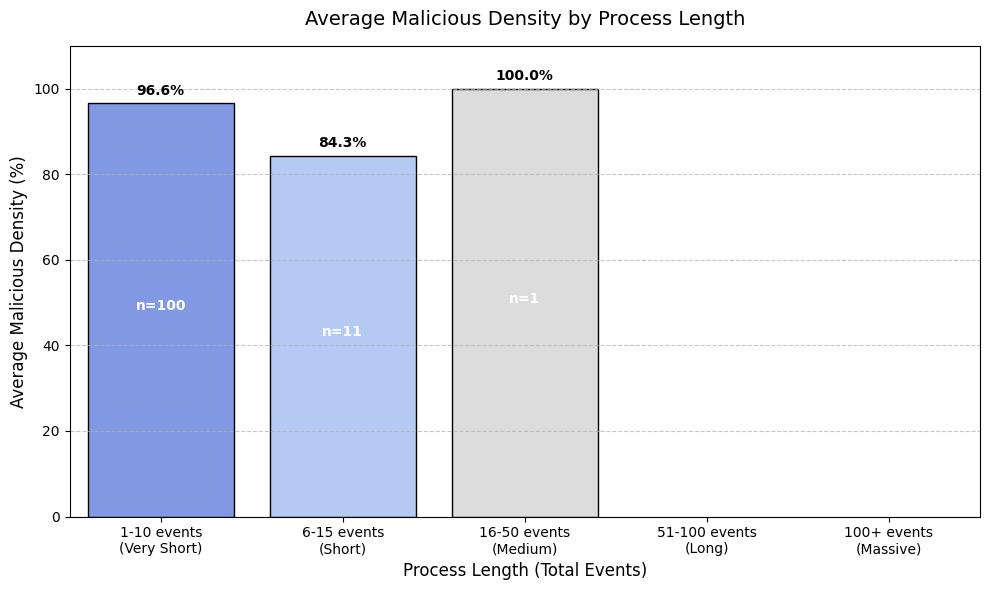

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# (Assuming 'stats_df' from your previous density cell is still in memory)

print("Generating Malware Density Histogram by Process Length...\n")

# 1. Define the buckets for Total Events (Process Length)
# We use custom bins based on typical process lifespans in Sysmon
bins = [0, 5, 15, 50, 100, 1000]
# bins = [0, 10, 20, 30, 40, 50]
labels = ['1-10 events\n(Very Short)', 
          '6-15 events\n(Short)', 
          '16-50 events\n(Medium)', 
          '51-100 events\n(Long)', 
          '100+ events\n(Massive)']

# 2. Assign each malicious process to a bucket based on its Total_Events
stats_df['Length_Bucket'] = pd.cut(stats_df['Total_Events'], bins=bins, labels=labels)

# 3. Calculate the Average Malicious Density for each bucket, AND count how many processes are in each bucket
bucket_stats = stats_df.groupby('Length_Bucket', observed=True).agg(
    Avg_Density=('Malicious_Percentage', 'mean'),
    Process_Count=('ProcessGuid', 'count')
).reset_index()

# 4. Plot the data using Seaborn
plt.figure(figsize=(10, 6))

# Create a bar plot
ax = sns.barplot(x='Length_Bucket', y='Avg_Density', data=bucket_stats, palette='coolwarm', edgecolor='black')

# Add the labels on top of the bars
for i, row in bucket_stats.iterrows():
    # Print the Density %
    ax.text(i, row['Avg_Density'] + 2, f"{row['Avg_Density']:.1f}%", 
            color='black', ha="center", fontweight='bold')
    
    # Print how many processes are in this bucket inside the bar
    ax.text(i, row['Avg_Density'] / 2, f"n={int(row['Process_Count'])}", 
            color='white', ha="center", fontweight='bold')

# Formatting
plt.title('Average Malicious Density by Process Length', fontsize=14, pad=15)
plt.xlabel('Process Length (Total Events)', fontsize=12)
plt.ylabel('Average Malicious Density (%)', fontsize=12)
plt.ylim(0, 110) # Keep Y-axis bounded to 100% (with a little headroom for labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating Normal Process Length Distribution...\n")

# 1. Filter down to just the Normal processes (Label == 0)
normal_guids = df_full[(df_full['Label'] == 0) & (df_full['ProcessGuid'].isin(guids_with_eid1))]['ProcessGuid'].unique()

if len(normal_guids) == 0:
    print("⚠️ No normal sequences found in the clean dataset!")
else:
    normal_stats = []
    
    # This might take 5-10 seconds since there are ~3,000 normal processes
    for guid in normal_guids:
        process_events = df_full[df_full['ProcessGuid'] == guid]
        total_events = len(process_events)
        
        normal_stats.append({
            'ProcessGuid': guid,
            'Total_Events': total_events
        })

    normal_df = pd.DataFrame(normal_stats)
    
    # 2. Define the exact same buckets we used for the Malicious graph
    bins = [0, 5, 15, 50, 100, 100000] # Set max very high in case normal processes live forever
    labels = ['1-5 events\n(Very Short)', 
              '6-15 events\n(Short)', 
              '16-50 events\n(Medium)', 
              '51-100 events\n(Long)', 
              '100+ events\n(Massive)']
              
    normal_df['Length_Bucket'] = pd.cut(normal_df['Total_Events'], bins=bins, labels=labels)
    
    # 3. Count how many normal processes are in each bucket
    bucket_counts = normal_df['Length_Bucket'].value_counts(sort=False).reset_index()
    bucket_counts.columns = ['Length_Bucket', 'Process_Count']
    
    # Calculate percentages for the labels
    total_normal = len(normal_df)
    bucket_counts['Percentage'] = (bucket_counts['Process_Count'] / total_normal) * 100
    
    # 4. Plot the data
    plt.figure(figsize=(10, 6))
    
    # We use a green palette for "Normal"
    ax = sns.barplot(x='Length_Bucket', y='Process_Count', data=bucket_counts, palette='Greens', edgecolor='black')
    
    # Add the labels
    for i, row in bucket_counts.iterrows():
        # Print the absolute count above the bar
        ax.text(i, row['Process_Count'] + (total_normal * 0.01), f"n={row['Process_Count']}", 
                color='black', ha="center", fontweight='bold')
        
        # Print the percentage inside the bar
        if row['Process_Count'] > 0:
            ax.text(i, row['Process_Count'] / 2, f"{row['Percentage']:.1f}%", 
                    color='black', ha="center", fontweight='bold')

    plt.title('Distribution of Normal (Benign) Process Lengths', fontsize=14, pad=15)
    plt.xlabel('Process Length (Total Events)', fontsize=12)
    plt.ylabel('Number of Processes', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Expand Y limit slightly to fit the top labels
    plt.ylim(0, bucket_counts['Process_Count'].max() * 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total Normal Processes Analyzed: {total_normal:,}")
    print(f"Average Length of a Normal Process: {normal_df['Total_Events'].mean():.1f} events")

Generating Normal Process Length Distribution...



KeyboardInterrupt: 

In [11]:
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset
import torch
import numpy as np
from tqdm import tqdm


print("1. Loading SecureBERT2.0 Tokenizer and Model...\n")

# Pretrained cybersecurity BERT model
model_name = "cisco-ai/SecureBERT2.0-base"

# Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load pretrained BERT encoder
model = AutoModel.from_pretrained(model_name)


print("2. Preparing Sysmon Dataset...\n")

# Keep the same logic: use your process-level BERT sequences
hf_dataset = Dataset.from_pandas(
    bert_documents[['BERT_Sequence', 'Label']]
)


def tokenize_sequences(examples):

    tokenized = tokenizer(
        examples["BERT_Sequence"],
        padding="max_length",
        truncation=True,
        max_length=512,
        return_attention_mask=True
    )

    return tokenized


tokenized_dataset = hf_dataset.map(
    tokenize_sequences,
    batched=True,
    remove_columns=["BERT_Sequence"]
)


print("3. Freezing SecureBERT and Extracting CLS Embeddings...\n")


# Enable hidden states output
model.config.output_hidden_states = True

# Evaluation mode (no training)
model.eval()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)


cls_embeddings = []

batch_size = 32


with torch.no_grad():

    for i in tqdm(
        range(0, len(tokenized_dataset), batch_size),
        desc="Extracting CLS"
    ):

        batch = tokenized_dataset[i:i+batch_size]


        input_ids = torch.tensor(
            batch["input_ids"]
        ).to(device)


        attention_mask = torch.tensor(
            batch["attention_mask"]
        ).to(device)



        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        # Last transformer layer
        last_hidden_state = outputs.hidden_states[-1]


        # CLS token representation (position 0)
        cls_vectors = last_hidden_state[:,0,:]


        cls_embeddings.extend(
            cls_vectors.cpu().numpy()
        )


print("\n✅ SecureBERT CLS feature extraction complete!")


# Convert to numpy array
X_features = np.array(cls_embeddings)


# Labels for classifier
y_labels = bert_documents["Label"].values


print("\nFeature Shape:")
print(X_features.shape)

print("\nLabel Shape:")
print(y_labels.shape)

c:\Users\Aarya.DAS\Downloads\model\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Loading SecureBERT2.0 Tokenizer and Model...



Loading weights: 100%|██████████| 134/134 [00:00<00:00, 1822.82it/s]
[transformers] ModernBertModel LOAD REPORT from: cisco-ai/SecureBERT2.0-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Preparing Sysmon Dataset...



Map: 100%|██████████| 2525/2525 [00:01<00:00, 2233.93 examples/s]


3. Freezing SecureBERT and Extracting CLS Embeddings...



Extracting CLS: 100%|██████████| 79/79 [51:24<00:00, 39.04s/it]


✅ SecureBERT CLS feature extraction complete!

Feature Shape:
(2525, 768)

Label Shape:
(2525,)


In [12]:
import numpy as np

print("1. Calculating Global Image Rarity...\n")
# Count how many logs exist for each Image in the dataset
image_counts = clean_df['Image'].value_counts()
total_logs = len(clean_df)

print("2. Extracting Advanced Math Features for Hybrid MLP...\n")
math_features_list = []

# We must loop through the exact same ProcessGuids that are in your bert_documents
# to guarantee the order matches the X_features (the 768-dim CLS vectors).
for guid in bert_documents['ProcessGuid']:
    
    # Grab the raw rows for this specific process
    process_rows = clean_df[clean_df['ProcessGuid'] == guid]
    
    if len(process_rows) > 0:
        # 1. Existing Features
        entropy = process_rows['dns_entropy'].max()
        unique_ip_count = process_rows['unique_ips'].max()
        beacon_score = process_rows['beaconing_interval_regularity'].max()
        spoofed = process_rows['is_parent_spoofed'].max()
        
        # 2. Obfuscation Density (Raw Math)
        obfuscation = process_rows['special_char_density'].max()
        
        # 3. Observed Process Lifetime (Seconds)
        time_min = process_rows['Time'].min()
        time_max = process_rows['Time'].max()
        lifetime = (time_max - time_min).total_seconds()
        
        # 4. Global Image Rarity
        img = process_rows['Image'].iloc[0]
        img_prevalence = (image_counts.get(img, 1) / total_logs) * 100
        rarity_score = 100.0 - img_prevalence
        
        # 5. NEW: Process Tree Depth
        # Extract the depth we calculated in Cell 1
        depth = process_rows['tree_depth'].max()
        
        # 6. NEW: Network Execution Delay
        # Extract the delay we calculated in Cell 1
        net_delay = process_rows['network_execution_delay'].max()
        
    else:
        # Fallback if somehow empty
        entropy, unique_ip_count, beacon_score, spoofed = 0.0, 0.0, 0.0, 0.0
        obfuscation, lifetime, rarity_score, depth, net_delay = 0.0, 0.0, 0.0, 1.0, -1.0
        
    # Append the 9 math features as a list
    math_features_list.append([entropy, unique_ip_count, beacon_score, spoofed, obfuscation, lifetime, rarity_score, depth, net_delay])

# Convert to a numpy array (Shape: Total_Sequences, 9)
Math_X = np.array(math_features_list)

print("3. Concatenating BERT [CLS] with Math Features...\n")

# hstack glues the 768 BERT features to the 9 Math features -> 777 Features total!
X_combined = np.hstack((X_features, Math_X))

print(f"Original BERT Shape: {X_features.shape}")
print(f"Math Features Shape: {Math_X.shape}")
print(f"✅ New Combined Shape: {X_combined.shape}")

1. Calculating Global Image Rarity...

2. Extracting Advanced Math Features for Hybrid MLP...

3. Concatenating BERT [CLS] with Math Features...

Original BERT Shape: (2525, 768)
Math Features Shape: (2525, 9)
✅ New Combined Shape: (2525, 777)


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

import warnings
import copy

warnings.filterwarnings("ignore", category=UserWarning)

print("1. Preparing Data for the MLP...\n")

# ============================================================
# 1. TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# 80% Training
# 10% Validation
# 10% Testing

X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

# Split remaining 20% into:
# 10% validation
# 10% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Training samples:   {len(X_train)} ({len(X_train)/len(X_combined)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X_combined)*100:.1f}%)")
print(f"Testing samples:    {len(X_test)} ({len(X_test)/len(X_combined)*100:.1f}%)\n")


# ============================================================
# 2. STANDARDIZATION
# ============================================================
# IMPORTANT:
# Fit scaler ONLY on training data.
# Then use the same scaler to transform validation and test.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# ============================================================
# 3. CONVERT TO PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


# ============================================================
# 4. CREATE DATA LOADERS
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print("2. Defining the Multi-Layer Perceptron (MLP)...\n")


# ============================================================
# 5. DEFINE MLP
# ============================================================

class MalwareClassifierMLP(nn.Module):

    def __init__(self, input_size):

        super(MalwareClassifierMLP, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),

            nn.BatchNorm1d(128),

            nn.LeakyReLU(0.01),

            nn.Dropout(0.3),

            nn.Linear(128, 32),

            nn.BatchNorm1d(32),

            nn.LeakyReLU(0.01),

            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 6. INITIALIZE MODEL
# ============================================================

mlp_model = MalwareClassifierMLP(
    input_size=X_combined.shape[1]
)

mlp_model.to(device)


# ============================================================
# 7. LOSS FUNCTION / OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([15.0]).to(device)
)

optimizer = optim.AdamW(
    mlp_model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


# ============================================================
# 8. TRAINING
# ============================================================

print("3. Training and Validating Epoch by Epoch...\n")

epochs = 15

# Store best model
best_val_f1 = 0.0
best_epoch = 0
best_model_state = None

# Store history for plotting later
train_loss_history = []
val_loss_history = []
val_f1_history = []


for epoch in range(epochs):

    # ========================================================
    # TRAINING PHASE
    # ========================================================

    mlp_model.train()

    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        predictions = mlp_model(batch_X)

        # Calculate loss
        loss = criterion(predictions, batch_y)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # UPDATE MODEL WEIGHTS
        optimizer.step()

        epoch_train_loss += loss.item()


    avg_train_loss = epoch_train_loss / len(train_loader)

    train_loss_history.append(avg_train_loss)


    # ========================================================
    # VALIDATION PHASE
    # ========================================================
    # IMPORTANT:
    # We use VALIDATION data every epoch.
    # We DO NOT use TEST data here.

    mlp_model.eval()

    val_loss = 0.0

    all_val_preds = []
    all_val_targets = []

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = mlp_model(batch_X)

            loss = criterion(logits, batch_y)

            val_loss += loss.item()

            probs = torch.sigmoid(logits)

            preds = (probs > 0.5).float()

            all_val_preds.extend(
                preds.cpu().numpy().flatten()
            )

            all_val_targets.extend(
                batch_y.cpu().numpy().flatten()
            )


    avg_val_loss = val_loss / len(val_loader)

    val_loss_history.append(avg_val_loss)


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_report = classification_report(
        all_val_targets,
        all_val_preds,
        target_names=[
            "Normal (0)",
            "Malicious (1)"
        ],
        output_dict=True,
        zero_division=0
    )

    val_mal_prec = val_report["Malicious (1)"]["precision"]
    val_mal_rec = val_report["Malicious (1)"]["recall"]
    val_mal_f1 = val_report["Malicious (1)"]["f1-score"]

    val_norm_prec = val_report["Normal (0)"]["precision"]
    val_norm_rec = val_report["Normal (0)"]["recall"]
    val_norm_f1 = val_report["Normal (0)"]["f1-score"]

    val_f1_history.append(val_mal_f1)


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(avg_val_loss)


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_mal_f1 > best_val_f1:

        best_val_f1 = val_mal_f1

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"=== EPOCH {epoch+1}/{epochs} ==="
    )

    print(
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Validation Loss: {avg_val_loss:.4f}"
    )

    print(
        f"Normal (0)    | "
        f"Precision: {val_norm_prec:.2f} | "
        f"Recall: {val_norm_rec:.2f} | "
        f"F1: {val_norm_f1:.2f}"
    )

    print(
        f"Malicious (1) | "
        f"Precision: {val_mal_prec:.2f} | "
        f"Recall: {val_mal_rec:.2f} | "
        f"F1: {val_mal_f1:.2f}"
    )

    print()


# ============================================================
# 9. LOAD BEST MODEL
# ============================================================

print("Training Complete!")

print(
    f"\nBest validation Malicious F1: "
    f"{best_val_f1:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

mlp_model.load_state_dict(best_model_state)


# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================
# IMPORTANT:
# Test set is used ONLY HERE.
# This is the final unbiased evaluation.

print("\n4. FINAL TEST SET EVALUATION...\n")

mlp_model.eval()

all_test_preds = []
all_test_targets = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)

        logits = mlp_model(batch_X)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float().cpu().numpy()

        all_test_preds.extend(
            preds.flatten()
        )

        all_test_targets.extend(
            batch_y.numpy().flatten()
        )


# ============================================================
# 11. FINAL TEST REPORT
# ============================================================

test_report = classification_report(
    all_test_targets,
    all_test_preds,
    target_names=[
        "Normal (0)",
        "Malicious (1)"
    ],
    zero_division=0
)

print("========== FINAL TEST RESULTS ==========\n")

print(test_report)

test_accuracy = accuracy_score(
    all_test_targets,
    all_test_preds
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

1. Preparing Data for the MLP...

Training samples:   2020 (80.0%)
Validation samples: 252 (10.0%)
Testing samples:    253 (10.0%)

2. Defining the Multi-Layer Perceptron (MLP)...

3. Training and Validating Epoch by Epoch...

=== EPOCH 1/15 ===
Train Loss: 0.9554 | Validation Loss: 0.7366
Normal (0)    | Precision: 1.00 | Recall: 0.76 | F1: 0.86
Malicious (1) | Precision: 0.16 | Recall: 1.00 | F1: 0.27

=== EPOCH 2/15 ===
Train Loss: 0.6952 | Validation Loss: 0.6145
Normal (0)    | Precision: 0.99 | Recall: 0.83 | F1: 0.90
Malicious (1) | Precision: 0.18 | Recall: 0.82 | F1: 0.30

=== EPOCH 3/15 ===
Train Loss: 0.5493 | Validation Loss: 0.4893
Normal (0)    | Precision: 1.00 | Recall: 0.89 | F1: 0.94
Malicious (1) | Precision: 0.27 | Recall: 0.91 | F1: 0.42

=== EPOCH 4/15 ===
Train Loss: 0.4643 | Validation Loss: 0.4732
Normal (0)    | Precision: 0.99 | Recall: 0.90 | F1: 0.94
Malicious (1) | Precision: 0.26 | Recall: 0.82 | F1: 0.40

=== EPOCH 5/15 ===
Train Loss: 0.3877 | Validatio

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress sklearn warnings about 0 precision early in training
warnings.filterwarnings('ignore', category=UserWarning)

print("1. Preparing Data for the MLP...\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("2. Defining the Multi-Layer Perceptron (MLP)...\n")

class MalwareClassifierMLP(nn.Module):
    def __init__(self, input_size):
        super(MalwareClassifierMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

mlp_model = MalwareClassifierMLP(input_size=X_combined.shape[1])
mlp_model.to(device)

# We adjust pos_weight slightly. 
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([15.0]).to(device))
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("3. Training and Evaluating Epoch by Epoch...\n")

epochs = 15
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    mlp_model.train() 
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        predictions = mlp_model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss/len(train_loader)
    scheduler.step(avg_train_loss)
    
    # --- EVALUATION PHASE (EVERY EPOCH) ---
    mlp_model.eval() 
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            logits = mlp_model(batch_X)
            probs = torch.sigmoid(logits)
            
            # Predict 1 if probability > 0.5
            preds = (probs > 0.5).float().cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(batch_y.numpy())

    # Generate the report as a dictionary so we can extract exact numbers safely
    report = classification_report(all_targets, all_preds, target_names=["Normal (0)", "Malicious (1)"], output_dict=True)
    
    # Extract metrics specifically for the Malicious class
    mal_prec = report['Malicious (1)']['precision']
    mal_rec = report['Malicious (1)']['recall']
    mal_f1 = report['Malicious (1)']['f1-score']
    
    # Extract metrics for Normal class
    norm_prec = report['Normal (0)']['precision']
    norm_rec = report['Normal (0)']['recall']
    norm_f1 = report['Normal (0)']['f1-score']

    print(f"=== EPOCH {epoch+1}/{epochs} (Loss: {avg_train_loss:.4f}) ===")
    print(f"Normal (0)    | Precision: {norm_prec:.2f} | Recall: {norm_rec:.2f} | F1: {norm_f1:.2f}")
    print(f"Malicious (1) | Precision: {mal_prec:.2f} | Recall: {mal_rec:.2f} | F1: {mal_f1:.2f}\n")


print("✅ Training Complete!")

1. Preparing Data for the MLP...

2. Defining the Multi-Layer Perceptron (MLP)...

3. Training and Evaluating Epoch by Epoch...

=== EPOCH 1/15 (Loss: 0.8085) ===
Normal (0)    | Precision: 0.99 | Recall: 0.84 | F1: 0.91
Malicious (1) | Precision: 0.19 | Recall: 0.82 | F1: 0.31

=== EPOCH 2/15 (Loss: 0.5644) ===
Normal (0)    | Precision: 0.99 | Recall: 0.91 | F1: 0.95
Malicious (1) | Precision: 0.29 | Recall: 0.77 | F1: 0.42

=== EPOCH 3/15 (Loss: 0.4539) ===
Normal (0)    | Precision: 0.99 | Recall: 0.93 | F1: 0.96
Malicious (1) | Precision: 0.35 | Recall: 0.82 | F1: 0.49

=== EPOCH 4/15 (Loss: 0.3689) ===
Normal (0)    | Precision: 0.99 | Recall: 0.90 | F1: 0.95
Malicious (1) | Precision: 0.29 | Recall: 0.86 | F1: 0.43

=== EPOCH 5/15 (Loss: 0.3558) ===
Normal (0)    | Precision: 0.98 | Recall: 0.95 | F1: 0.97
Malicious (1) | Precision: 0.38 | Recall: 0.68 | F1: 0.49

=== EPOCH 6/15 (Loss: 0.3315) ===
Normal (0)    | Precision: 0.99 | Recall: 0.92 | F1: 0.95
Malicious (1) | Precisio

In [14]:
print("3. Training the MLP with Class Weights...\n")

# Calculate the imbalance ratio: (Count of Normal) / (Count of Malicious)
#We will calculate it dynamically from the training set.
num_normal = (y_train == 0).sum()
num_malicious = (y_train == 1).sum()
weight_ratio = num_normal / (num_malicious + 1e-5) # Add tiny number to prevent divide by zero
print(f"Applying Malicious Penalty Weight: {weight_ratio:.2f}x")

# We use BCEWithLogitsLoss because it natively supports pos_weight for imbalanced datasets
# (Note: BCEWithLogitsLoss automatically applies Sigmoid, so we should technically 
# remove the nn.Sigmoid() from the end of our Neural Network class, but PyTorch handles it).
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight_ratio]).to(device))

optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

epochs = 15
for epoch in range(epochs):
    mlp_model.train() 
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        predictions = mlp_model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader):.4f}")

print("\n4. Evaluating the MLP on Test Data...\n")

mlp_model.eval() 
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        probs = torch.sigmoid(mlp_model(batch_X)) # Apply sigmoid to get probability
        
        # We lower the decision threshold slightly to favor catching malware (Recall)
        preds = (probs > 0.4).float().cpu().numpy()
        
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

# Print Final Accuracy Metrics
acc = accuracy_score(all_targets, all_preds)
print(f"✅ Final Test Accuracy: {acc * 100:.2f}%\n")
print(classification_report(all_targets, all_preds, target_names=["Normal (0)", "Malicious (1)"]))

3. Training the MLP with Class Weights...

Applying Malicious Penalty Weight: 21.44x
Epoch 1/15 | Loss: 0.2977
Epoch 5/15 | Loss: 0.4212
Epoch 10/15 | Loss: 0.1972
Epoch 15/15 | Loss: 0.1691

4. Evaluating the MLP on Test Data...

✅ Final Test Accuracy: 94.86%

               precision    recall  f1-score   support

   Normal (0)       1.00      0.95      0.97       242
Malicious (1)       0.46      1.00      0.63        11

     accuracy                           0.95       253
    macro avg       0.73      0.97      0.80       253
 weighted avg       0.98      0.95      0.96       253



In [ ]:
# Cell 8 — score a whole test JSONL against the frozen baselines.
# Depends on Cell 1: BASELINE_DIR
# Depends on Cell 6: score_event
# Depends on Cell 7: add_deviation
# Test file format = same as training: one Winlog JSON object per line.

TEST_PATH = Path("data/data.jsonl")     # <-- put your new file here
SCORE_OUT = BASELINE_DIR / "test_scores.json"
THRESHOLD = 0.60                        # print full field table at/above this


def load_jsonl(path: Path):
    events = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    return events


def score_file(path: Path, threshold: float = THRESHOLD):
    if not path.exists():
        print(f"no test file at {path}")
        print("put a JSONL there (same schema as training) and re-run this cell.")
        return []

    raw = load_jsonl(path)
    rows = []
    for i, ev in enumerate(raw):
        result = add_deviation(score_event(ev))
        result["index"] = i
        rows.append(result)

    # compact table, highest score first
    ranked = sorted(rows, key=lambda r: (-1 if r["score"] is None else -r["score"], r["index"]))
    print(f"scored {len(rows)} events from {path}")
    print(f"{'#':>4}  {'score':>5}  {'eid':>5}  {'user':<24} {'host':<8}  unseen / note")
    for r in ranked:
        score_s = " n/a" if r["score"] is None else f"{r['score']:.2f}"
        unseen = [f["field"] for f in r.get("fields", []) if not f.get("in_baseline")]
        tail = r["note"] or (", ".join(unseen) if unseen else "-")
        print(f"{r['index']:4}  {score_s:>5}  {r['event_id']:>5}  "
              f"{str(r['user'] or '-'):<24} {str(r['host'] or '-'):<8}  {tail}")

    flagged = [r for r in ranked if r["score"] is not None and r["score"] >= threshold]
    print(f"\n{len(flagged)} event(s) >= {threshold}")
    for r in flagged:
        print_deviation(r)

    # drop nothing needed for JSON — datetime already gone
    out = []
    for r in rows:
        out.append({
            "index": r["index"],
            "user": r["user"],
            "event_id": r["event_id"],
            "host": r["host"],
            "hour": r["hour"],
            "score": r["score"],
            "note": r["note"],
            "event_in_baseline": r["event_in_baseline"],
            "baseline_event_count": r["baseline_event_count"],
            "count_only": r["count_only"],
            "fields": r["fields"],
        })
    SCORE_OUT.write_text(json.dumps(out, indent=2))
    print(f"\nwrote {SCORE_OUT}")
    return rows


test_rows = score_file(TEST_PATH)

NameError: name 'BASELINE_DIR' is not defined